# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [39]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

Cantidad_de_valores_nulos = users[['city', 'churn_date']].isna().sum()
Proporción_de_valores_nulos = users[['city', 'churn_date']].isna().mean() * 100


print('Cantidad de valores nulos:')
print()
print(Cantidad_de_valores_nulos)
print()
print('Proporción de valores nulos:')
print()
print(Proporción_de_valores_nulos)


Cantidad de valores nulos:

city           469
churn_date    3534
dtype: int64

Proporción de valores nulos:

city          11.725
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
Cantidad_de_valores_nulos = usage[['date', 'duration', 'length']].isna().sum()
Proporción_de_valores_nulos = usage[['date', 'duration', 'length']].isna().mean() * 100

print('Cantidad de valores nulos:')
print()
print(Cantidad_de_valores_nulos)
print()
print('Proporción de valores nulos:')
print()
print(Proporción_de_valores_nulos)


Cantidad de valores nulos:

date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:

date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Encontramos valores nulos en diferentes columnas:

users presenta valores nulos en las columnas city y churn_date, sin embargo, los valores nulos de churn_date representan a los usuarios activos, por tal razón no se tomará acción en esta. Por otro lado, la columna city presenta un 11,72% de valores nulos, se recomienda una investigación que nos determine el porqué de esta ausencia, no podemos ignorar o eliminar, ya que esto nos sesgaría la trazabilidad del análisis, además, encontramos caracteres especiales ("?") en esta columna, se debe revisar detalladamente estos.  

usage presenta valores nulos en las columnas date, duration, length. Al entender la información de estas columnas encontramos que valores de duration y length nos representan un 100% de datos, los nulos en una columna son valores no nulos de la otra. Por otro lado la columna de date que contiene el 0.125% nulos podríamos imputarlos para tener un análisis más detallado  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: es el número de usuario único del cliente y nos muestra que estamos analizando 4000 clientes  
- La columna `age`: muestra que tenemos valores inválidos como -999. Y la diferencia de media y mediana nos indica un sesgo a la izquierda que altera la media.

In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`
- Las columnas id y user_id son indicativos unicos que corresponden a un usurio unico y a un uso unico de un servicio, por lo tanto en estos valores no se ven afectados por media o mediana. 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` nos muestra que tenemos 3531 entradas (469 NaN), con 7 ciudades únicas de las cuales Bogotá se sitúa en la cabeza con 808 usuarios de esta ciudad. Sin embargo, se debe revisar detalladamente cuántos son los valores únicos, pues se encontraron caracteres especiales en la columna como ("?") que tiene un total de 96 valores.
- La columna `plan` tenemos dos planes únicos donde el plan básico es el plan con mayor acogida por nuestros clientes con 2595 usuarios. 

In [15]:
caracter_especial = users['city'].isin(['?']).sum()
print(caracter_especial)

96


In [16]:
# explorar columna categórica de usage
columnas_usage = ['type']
usage[columnas_usage].describe()

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` tiene dos tipos únicos de comunicación, en donde la comunicación por medio de texto se sitúa en el top con un total de 22092 entradas. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Nuestro análisis muestra que la columna 'age' de nuestro dataset 'users' presenta sentinels como (-999) que podemos reemplazar por la mediana de esta columna, ya que la media está afectada por los mismos sentinels.

Para nuestra columna 'city' de nuestro dataset 'users' presenta valores invalidos como '?' con un total de 96 valores, recomendamos reemplazarlos por ausentes.
una vez realizado este reemplazo, es recomendable asignarle una categoría 'unknown' a todos los ausentes de esta columna, ya que eliminarlos o no tomarlos en cuenta afectaría la trazabilidad del análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users

print(users['reg_date'].dt.year.unique())
print(users['reg_date'].isna().sum())

[2022 2026 2023 2024]
0


En `reg_date` despues de formatear encontramos que tenemos registros de los años 2022, 2023, 2024, 2026 sin valores nulos, a su vez nos muestra fechas futuras como 2026. Nuestro dataframe tiene registros solo hasta el año 2024

In [20]:
# Revisar los años presentes en `date` de usage

print(usage['date'].dt.year.unique())
print(usage['date'].isna().sum())

[2024.   nan]
50


En `date` encontramos solo los registros del año 2024 que son los pertinentes para nuestro análisis. En esta volvemos a presenciar la ausencia de valores en 50 filas, las cuales representan el 0,12% del total de filas, el no tomarlas en cuenta para nuestro análisis no afectará la trazabilidad de nuestro análisis.  

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Debemos revisar la procedencia de los datos, ya que encontramos años que aún no han transcurrido (2026). Se debe verificar con la fuente, ya que puede tratarse de un error de digitación o de captura. 
Se recomienda reemplazarlos por ausentes, si la validación con el equipo muestra que no es posible obtener el dato origninal

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [40]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [41]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].unique())

['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']


In [23]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan

# Verificar cambios
print(users['reg_date'].dt.year.unique())


[2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
usage[['type', 'duration', 'length']].head(10)


,type,duration,length
0,call,0.09,NaN
1,text,NaN,39.0
2,text,NaN,36.0
3,call,1.53,NaN
4,call,4.84,NaN
5,call,4.68,NaN
6,call,3.27,NaN
7,call,4.81,NaN
8,text,NaN,44.0
9,text,NaN,70.0


In [25]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_duration = usage['duration'].isna().sum()
print('valores nulos en duration:' ,nulos_duration)


valores nulos en duration: 22076


In [26]:
# Verificación MAR en usage (Missing At Random) para length 
nulos_length = usage['length'].isna().sum()
print('valores nulos en length:' ,nulos_length)

valores nulos en length: 17896


In [43]:
filas_con_ambos_valores = (usage['duration'].notna() & usage['length'].notna()).sum()
print('encontramos filas con ambos valores:' ,filas_con_ambos_valores)

encontramos filas con ambos valores: 28


In [28]:
datos_totales_columnas  = nulos_duration + nulos_length + filas_con_ambos_valores
print(datos_totales_columnas)

40000


Haz doble clic aquí y escribe que tu diagnóstico de nulos en `duration` y `length`

las columnas 'duration' y 'length' dependen totalmente de la columna 'type', si se realizó una llamada 'type = call' la columna duration presentará un valor en minutos y length estará nula pues esta corresponde a largo del texto, de la misma manera sucederá en manera contraria si 'type = text'. Sin embargo, en las revisiones pertinentes encontramos 28 filas que comparten ambos valores.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Renombrar columnas
usage_clean = usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call':'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_clean.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_clean, on='user_id', how='left')
user_profile.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas

user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [33]:
# Distribución porcentual del tipo de plan
dist_pct_plan = (user_profile['plan'].value_counts()/ len(user_profile)) * 100

print(dist_pct_plan)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

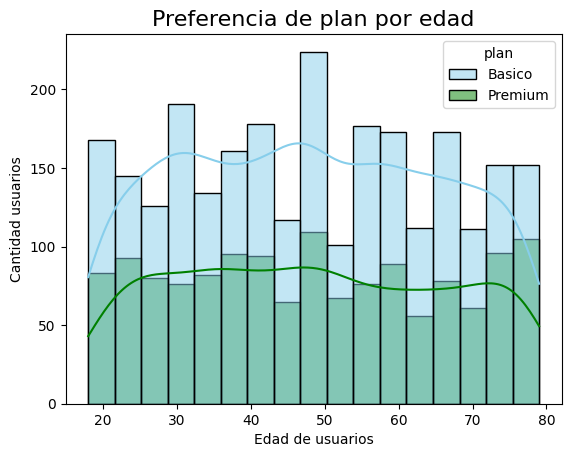

In [34]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True )
plt.xlabel('Edad de usuarios')
plt.ylabel('Cantidad usuarios')
plt.title('Preferencia de plan por edad', fontsize=16)
plt.show()

💡Insights: 
- Su distribución es simétrica y nos deja observar que el plan de mayor preferencia de nuestros usuarios es el Plan Básico con mayor demanda entre las edades de  47 y 50 años.  

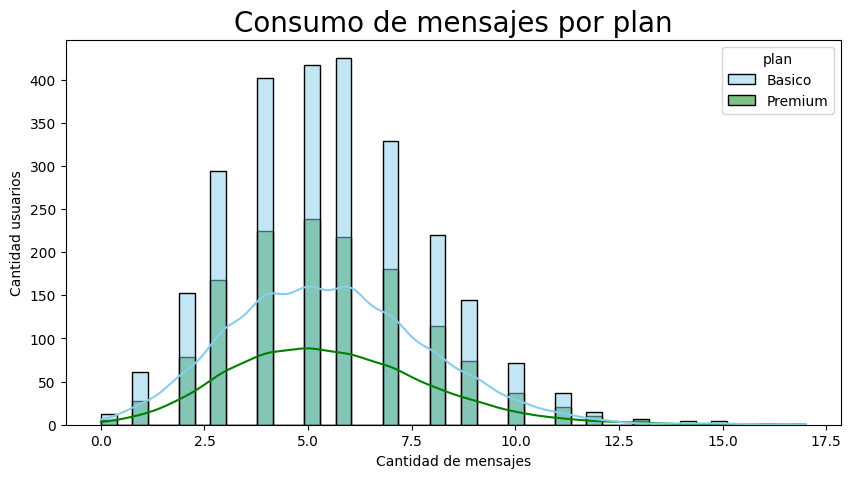

In [35]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize= (10,5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True )
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad usuarios')
plt.title('Consumo de mensajes por plan', fontsize=20)
plt.show()

💡Insights: 
- Encontramos una distribución sesgada hacia la derecha, indicándonos que un pequeño nicho de usuarios disfruta la comunicación por mensajes; sin embargo, la mayor cantidad de usuarios envía un promedio de 5 mensajes de texto, especialmente usuarios de nuestro plan Básico, a su vez los usuarios del plan Premium también comparten este mismo promedio de 5 mensajes. 

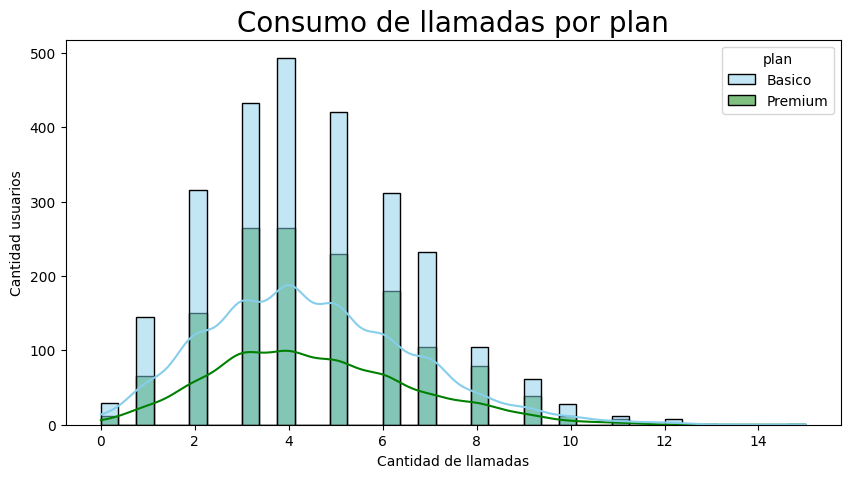

In [36]:
# Histograma para visualizar la cant_llamadas

plt.figure(figsize= (10,5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True )
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad usuarios')
plt.title('Consumo de llamadas por plan', fontsize=20)
plt.show()

💡Insights: 
- Distribución sesgada muy poco hacia la derecha, el promedio de llamadas por usuario se mantiene en 4 llamadas, siendo más alto en nuestro plan Básico, sin embargo, el plan Premiun también comparte el promedio, algunos usuarios (muy pocos) tienden a utilizar más este medio de comunicación con un  promedio de 15 llamadas. 

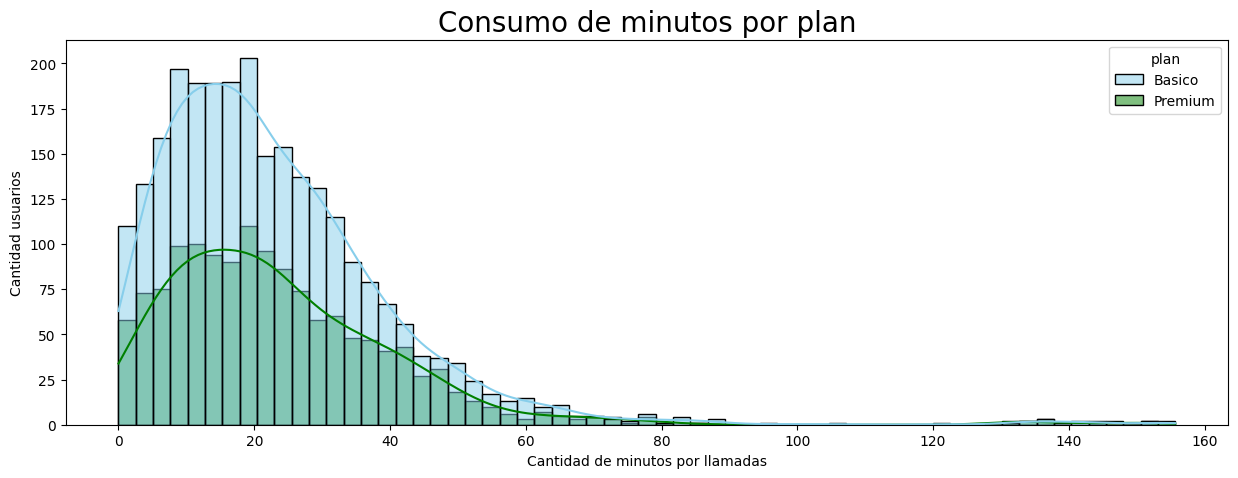

In [37]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize= (15,5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True )
plt.xlabel('Cantidad de minutos por llamadas')
plt.ylabel('Cantidad usuarios')
plt.title('Consumo de minutos por plan', fontsize=20)
plt.show()

💡Insights: 
- Vemos un sesgo hacia la derecha, indicándonos la cantidad de minutos que algunos usuarios consumen, nuevamente el plan Básico es nuestro plan con mayor demanda de minutos con un promedio de 19 minutos, también es el promedio de nuestros usuarios del plan Premium. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

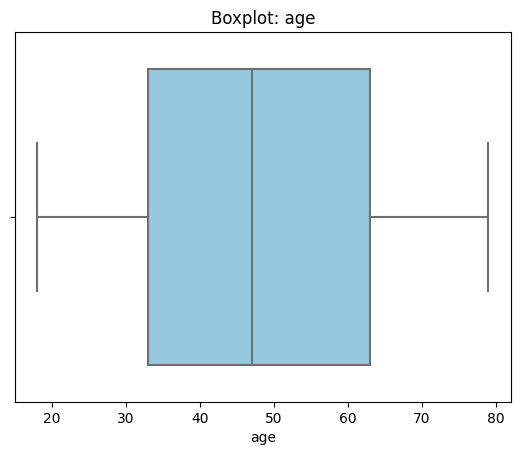

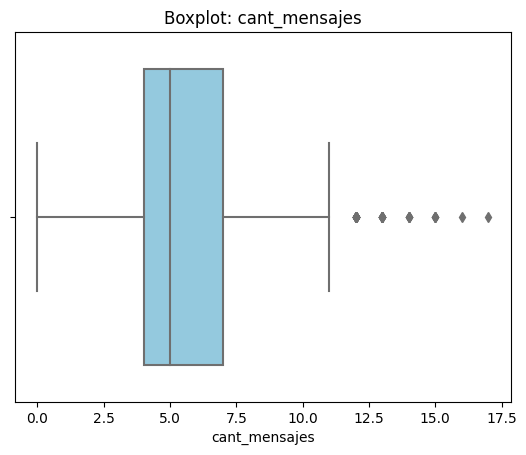

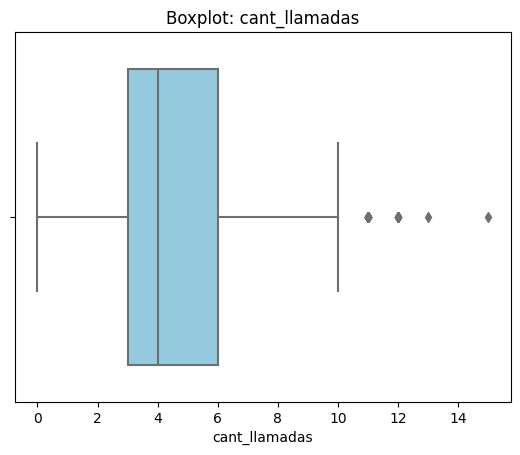

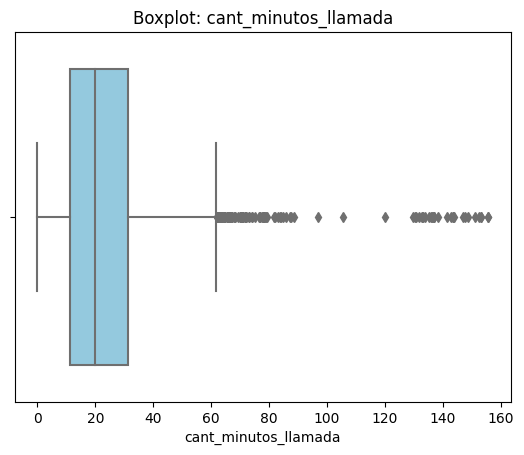

In [53]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
     sns.boxplot(x=user_profile[col], color='skyblue')
     plt.title(f'Boxplot: {col}')
     plt.show()

    

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta outliers, pero a la vez son valores posibles ya que pueden existir usuarios que prefieren este tipo de comunicación, pero puede sesgar el analisis. 
- cant_llamadas: de la misma manera que la cantidad de mensajes, presenta outliers pero no se puede determinar como outlier ya que es un valor posible, pero puede sesgar el analisis
- cant_minutos_llamada: presenta outliers, valores posibles, pero puede sesgar el análisis. 

In [77]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    
    q1=user_profile[col].quantile(0.25)
    q3=user_profile[col].quantile(0.75)
    
    iqr=q3 - q1
    
    extremo_superior = q3 + 1.5*iqr
    
    print(f'analisis en: {col}')
    print(f'IQR: {iqr} ')
    print(f'limite sperior: {extremo_superior} ')
    print()

analisis en: cant_mensajes
IQR: 3.0 
limite sperior: 11.5 

analisis en: cant_llamadas
IQR: 3.0 
limite sperior: 10.5 

analisis en: cant_minutos_llamada
IQR: 20.295 
limite sperior: 61.8575 



In [78]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se conservan los registros. Aunque los valor máximo (17) supera el límite superior calculado (11.5), la desviación es leve. Estos representan usuarios reales con alta actividad, si se excluyen, manipulariams el real comportamiento de uso del servicio. 
- cant_llamadas: Al igual que con los mensajes, se deben mantener los valores, la desvicion es leve max (15) y limite superior (10.5), eliminarlos o excluirlos manipularia los resultados. 
- cant_minutos_llamada: se deben winsorizar. El valor máximo (155.69) representa un outlier extremo respecto al límite superior (61.85). Mantenerlo desplazaría artificialmente la media hacia arriba, sesgando las conclusiones sobre el consumo típico del cliente.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [94]:
# Crear columna grupo_uso
def segmentacion_clientes(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    #if pd.isna(mensajes) or pd.isna(llamadas): NO ESTOY MUY SEGURO SI DEBA LLEVAR ESTA VERIFICACION
        #return 'erros de datos'
        
    if mensajes < 5 and llamadas < 5:
        return 'Bajo uso'
    elif mensajes < 10 and llamadas < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentacion_clientes, axis=1)

In [84]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [97]:
# Crear columna grupo_edad
def clientes_edad(row):
    edad = row['age']

    if pd.isna(edad):
        return 'error de datos'

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clientes_edad, axis=1)


In [90]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

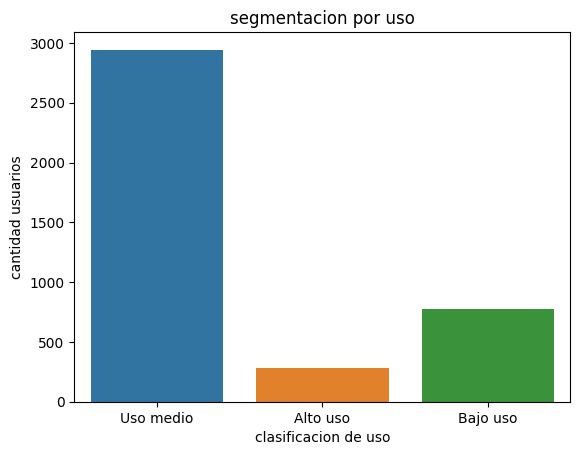

In [98]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('segmentacion por uso')
plt.xlabel('clasificacion de uso')
plt.ylabel('cantidad usuarios')

plt.show()


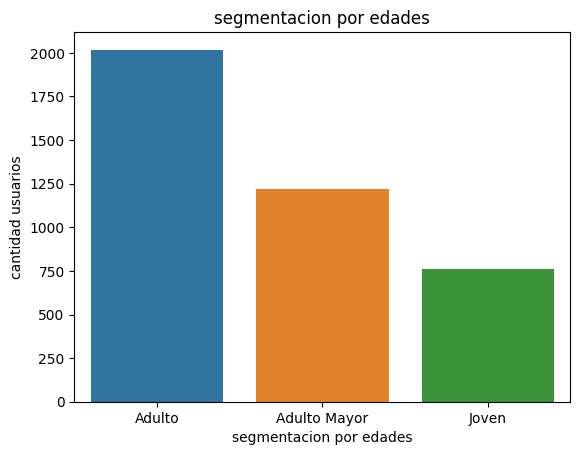

In [99]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('segmentacion por edades')
plt.xlabel('segmentacion por edades')
plt.ylabel('cantidad usuarios')

plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Los datos fueron entregados en 3 datasets diferentes, encontramos datos ausentes, caracteres especiales, y valores nulos:
- En el dataset ‘users’ la columna ‘city’ fue la columna más comprometida para nuestro análisis, ya que presentaba un 11,72% de datos ausentes, y  96 filas con caracteres especiales. 
- El dataset ‘usage’ encontramos datos ausentes y fechas futuras, los datos ausentes en la columna ‘date’ representaban solo el 0.125%, mientras que las columnas ‘duration’ y ‘length’ presentaban ausencias superiores al 40%, pero se encontró que son valores MAR que tenían una correlación con la columna ‘type’ , esta ausencia no afectaba nuestro análisis. 


🔍 **Segmentos por Edad**

Encontramos que nuestro plan básico, es el plan con mayor demanda en nuestro segmento de edades adultas (mayores de 30 y menores de 60) especialmente los adultos entre edades 47 a 50 años. Nuestros otros segmentos presentaron la misma preferencia en nuestro plan básico. 

📊 **Segmentos por Nivel de Uso**

Los usuarios de nuestro segmento de adultos presentan una preferencia por nuestro plan básico con uso medio. Esto nos determina que los usuarios adultos son nuestro segmento mas valioso. 

➡️ Esto sugiere: 

💡 **Recomendaciones**

Basado en el análisis de segmentación y patrones de consumo detectados, podría plantear las siguientes recomendaciones:
- Se puede crear un plan intermedio (minutos y mensajes adicionales) dirigido a nuestro segmento adulto, donde una mejora pequeña de plan puede generar un impacto masivo en los ingresos sin necesidad de adquirir nuevos clientes.
- Nuestros usuarios extremos (outliers), pueden convertirse en una oportunidad para nuestra compañía. Se puede crear un business plan para ellos, donde ofrecemos más beneficios. Ya que estos usuarios pueden estar usando el servicio con fines específicos. Y esto generó mayores ingresos. 
- Se aconseja incentivar nuestro segmento joven, ya que podríamos fidelizarlos de por vida y capturar estos usuarios a largo plazo. La creación de un plan más ajustado a la necesidad de ellos puede ser nuestra dirección. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`